<a href="https://colab.research.google.com/github/chiangjasmine2026/ADALL_github/blob/main/ADALL%20Project%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install -U \
  scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
print("Setup complete")

Setup complete


In [3]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.8.0


In [4]:
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

Successfully loaded data from GitHub!


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
#change the value 2.0 to 1.0 in column Diabetes_012
df['Diabetes_012'] = df['Diabetes_012'].replace(2.0, 1.0)

In [5]:
import pandas as pd
import numpy as np
from io import StringIO
# ---------------------------
# Generate a full dataset profile
# ---------------------------
buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)


=== DTYPES ===
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64

=== NUMERIC DESCRIBE ===
        Diabetes_012         HighBP       HighChol      CholCheck            BMI         Smoker         Stroke  HeartDiseaseorAttack   PhysActivity         Fruits        Veggies  HvyAlcoholConsump  AnyHealthcare    NoDocbcCost        GenHlth       MentHlt

In [7]:
from google.colab import userdata
from openai import OpenAI
# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(
    api_key=api_key,
)

In [8]:
# response = client.responses.create(
#     model="gpt-5-mini",
#     instructions="""
# You are an expert data scientist with extensive knowledge of tree-based models.
# Always justify recommendations using reasoning trace based ONLY on the dataset profile.
# """,
#     input=f"""
# Dataset info: {payload_text}\n
# Questions:\n
# 1. Based on the dataset profile, what data quality issues should be resolved before modelling?
# Provide a priority list and justify each item. \n
# 2. Which columns appear redundant, correlated, or likely to cause leakage?
# Explain why each is problematic. \n
# Next: Provide a python script to handle the identified issues.
# Define one helper function for each issue.
# Then define a wrapper function that calls these helper with true false option as user choice
# Provide a single line of code to run the overall wrapper function.
# Do not encode categorical columns or model first.
# """)
# print(response.output_text)

In [9]:
import pandas as pd
import numpy as np
from sklearn.utils import resample

def check_missing_and_duplicates(df, verbose=True):
    """Check for missing values and duplicates. Returns df unchanged but raises if missing present when verbose=True."""
    missing = df.isnull().sum()
    total_missing = missing.sum()
    if verbose:
        print("Total missing values:", int(total_missing))
        if total_missing > 0:
            print(missing[missing > 0])
        dup_count = df.duplicated(keep=False).sum()
        print("Duplicate rows count:", int(dup_count))
    return df

def drop_constant_columns(df, verbose=True):
    """Drop any constant columns (zero variance)."""
    nunique = df.nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    if verbose:
        print("Constant columns to drop:", const_cols)
    if const_cols:
        df = df.drop(columns=const_cols)
    return df

def remove_highly_correlated(df, target_col='target', threshold=0.95, verbose=True):
    """
    Remove highly correlated features (pairwise abs corr > threshold).
    For each correlated pair, keep the column with larger absolute Pearson correlation with target_col.
    """
    # work on numeric columns only
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col not in numeric:
        raise ValueError("target_col must be numeric and present in df")
    features = [c for c in numeric if c != target_col]
    corr = df[features].corr().abs()

    to_drop = set()
    # precompute abs correlation with target
    abs_corr_with_target = df[features].corrwith(df[target_col]).abs()

    # iterate upper triangle pairs
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            c1 = cols[i]; c2 = cols[j]
            if corr.iloc[i, j] > threshold:
                # compare correlation with target; if equal use variance as tie-breaker (drop the lower variance)
                corr1 = abs_corr_with_target.get(c1, 0.0)
                corr2 = abs_corr_with_target.get(c2, 0.0)
                if corr1 > corr2:
                    drop_col = c2
                elif corr2 > corr1:
                    drop_col = c1
                else:
                    # tie-breaker: drop the one with smaller variance
                    var1 = df[c1].var()
                    var2 = df[c2].var()
                    drop_col = c1 if var1 < var2 else c2
                # don't drop target accidentally
                if drop_col != target_col:
                    to_drop.add(drop_col)

    if verbose:
        print(f"Removing {len(to_drop)} highly correlated columns (threshold={threshold}):", sorted(list(to_drop)))
    df = df.drop(columns=list(to_drop))
    return df

def cap_outliers_iqr(df, multiplier=1.5, exclude=None, verbose=True):
    """
    Cap values outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR] for numeric columns.
    exclude: list of columns to exclude from capping (e.g., target_col). By default exclude 'target' if present.
    """
    if exclude is None:
        exclude = []
    if 'target' in df.columns and 'target' not in exclude:
        exclude = exclude + ['target']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_cap = [c for c in numeric_cols if c not in exclude]
    capped_info = {}
    for col in cols_to_cap:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before_min = df[col].min()
        before_max = df[col].max()
        df[col] = df[col].clip(lower=lower, upper=upper)
        after_min = df[col].min()
        after_max = df[col].max()
        capped_info[col] = (before_min, before_max, after_min, after_max)
    if verbose:
        # Print a brief summary for columns that changed ranges
        changed = {k:v for k,v in capped_info.items() if v[0]!=v[2] or v[1]!=v[3]}
        print("Columns with range changes after IQR capping:", list(changed.keys()))
    return df

def resample_classes(df, target_col='target', method='none', random_state=42, verbose=True):
    """
    Resample dataset to address class imbalance.
    method options: 'none' | 'oversample' | 'undersample'
    - oversample: upsample minority class to match majority
    - undersample: downsample majority class to match minority
    Returns a new DataFrame (shuffled).
    """
    if method not in ('none', 'oversample', 'undersample'):
        raise ValueError("method must be one of 'none','oversample','undersample'")
    if method == 'none':
        if verbose:
            print("No resampling performed.")
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # split classes
    classes = df[target_col].unique().tolist()
    if len(classes) != 2:
        raise ValueError("resample_classes currently supports binary target only")
    class0 = df[df[target_col] == classes[0]]
    class1 = df[df[target_col] == classes[1]]
    # determine majority/minority
    if len(class0) > len(class1):
        majority, minority = class0, class1
    else:
        majority, minority = class1, class0

    if method == 'oversample':
        minority_up = resample(minority,
                               replace=True,
                               n_samples=len(majority),
                               random_state=random_state)
        df_resampled = pd.concat([majority, minority_up], axis=0)
    else:  # undersample
        majority_down = resample(majority,
                                 replace=False,
                                 n_samples=len(minority),
                                 random_state=random_state)
        df_resampled = pd.concat([majority_down, minority], axis=0)

    df_resampled = df_resampled.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    if verbose:
        counts = df_resampled[target_col].value_counts().to_dict()
        print(f"Resampled class counts ({method}):", counts)
    return df_resampled

def preprocess_dataset(df,
                       target_col='target',
                       remove_constants=True,
                       remove_correlated=True,
                       corr_threshold=0.95,
                       cap_outliers=True,
                       outlier_multiplier=1.5,
                       resample_method='none',
                       random_state=42,
                       verbose=True):
    """
    Wrapper that runs a sequence of preprocessing steps. Each step can be toggled.
    Returns the processed DataFrame.
    """
    # 1) Basic checks
    if verbose:
        print("Starting preprocessing...")
    df = check_missing_and_duplicates(df, verbose=verbose)

    # 2) Drop constant columns
    if remove_constants:
        df = drop_constant_columns(df, verbose=verbose)

    # 3) Remove highly correlated features
    if remove_correlated:
        df = remove_highly_correlated(df, target_col=target_col, threshold=corr_threshold, verbose=verbose)

    # 4) Cap outliers
    if cap_outliers:
        df = cap_outliers_iqr(df, multiplier=outlier_multiplier, exclude=[target_col], verbose=verbose)

    # 5) Resample for class imbalance (if requested)
    if resample_method != 'none':
        df = resample_classes(df, target_col=target_col, method=resample_method, random_state=random_state, verbose=verbose)
    else:
        if verbose:
            print("Skipping resampling step.")

    if verbose:
        print("Preprocessing complete. Resulting shape:", df.shape)
    return df

df_clean = preprocess_dataset(df,
                              target_col='target',
                              remove_constants=False,
                              remove_correlated=False,
                              corr_threshold=0.95,
                              cap_outliers=False,
                              outlier_multiplier=1.5,
                              resample_method='none',
                              random_state=42,
                              verbose=True)


Starting preprocessing...
Total missing values: 0
Duplicate rows count: 35212
Skipping resampling step.
Preprocessing complete. Resulting shape: (253680, 22)


In [10]:
TARGET_COL = "Diabetes_012"  # change for your dataset
df[TARGET_COL].value_counts()

,count
Diabetes_012,
0.0,213703
1.0,39977


In [11]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((202944, 21), (50736, 21))

In [12]:
num_cols = X_train.select_dtypes(exclude=["object","category"]).columns
cat_cols = X_train.select_dtypes(include=["object","category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

num_cols[:10], cat_cols[:10]


(Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
        'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies'],
       dtype='object'),
 Index([], dtype='object'))

In [13]:
# ------------------------------------
# Decision Tree (Classification) + GridSearch (MCC) + Print Tree
# ------------------------------------

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import matthews_corrcoef, make_scorer

# Stratified CV keeps class balance similar across splits
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# MCC scorer (higher is better)
mcc_scorer = make_scorer(matthews_corrcoef)

# -------------------------------------------
# 1) Pipeline
# -------------------------------------------
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# -------------------------------------------
# 2) Small param grid (fast)
# -------------------------------------------
param_grid_dt = {
    "classifier__max_depth": [8, 15], #lets use a deeper tree to illustrate the need for Feature Importance
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

# -------------------------------------------
# 3) GridSearchCV
# -------------------------------------------
gs_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_grid_dt,
    cv=cv,
    scoring=mcc_scorer,
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4) Fit
# -------------------------------------------
gs_dt.fit(X_train, y_train)
print("Decision Tree grid search complete.")
print("Best DT Params:", gs_dt.best_params_)
print("Best CV MCC:", gs_dt.best_score_)

# -------------------------------------------
# 5) Test MCC
# -------------------------------------------
dt_best = gs_dt.best_estimator_
dt_pred = dt_best.predict(X_test)
print("\nTest MCC (Decision Tree):", matthews_corrcoef(y_test, dt_pred))

# -------------------------------------------
# 6) Print the tree rules (text)
# -------------------------------------------
# Get feature names after preprocessing (works for ColumnTransformer in recent sklearn)
pre = dt_best.named_steps["preprocessor"]
clf = dt_best.named_steps["classifier"]

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = [f"f{i}" for i in range(clf.n_features_in_)]

tree_text = export_text(clf, feature_names=list(feature_names), max_depth=6)
print("\nDecision Tree (first 6 levels):\n")
print(tree_text)




Fitting 10 folds for each of 6 candidates, totalling 60 fits
Decision Tree grid search complete.
Best DT Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 8}
Best CV MCC: 0.24093799261870902

Test MCC (Decision Tree): 0.23685634157468655

Decision Tree (first 6 levels):

|--- num__HighBP <= 0.50
|   |--- num__GenHlth <= 2.50
|   |   |--- num__Age <= 8.50
|   |   |   |--- num__BMI <= 28.50
|   |   |   |   |--- num__GenHlth <= 1.50
|   |   |   |   |   |--- num__Income <= 7.50
|   |   |   |   |   |   |--- num__HighChol <= 0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__HighChol >  0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- num__Income >  7.50
|   |   |   |   |   |   |--- num__Sex <= 0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |--- num__Sex >  0.50
|   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |-

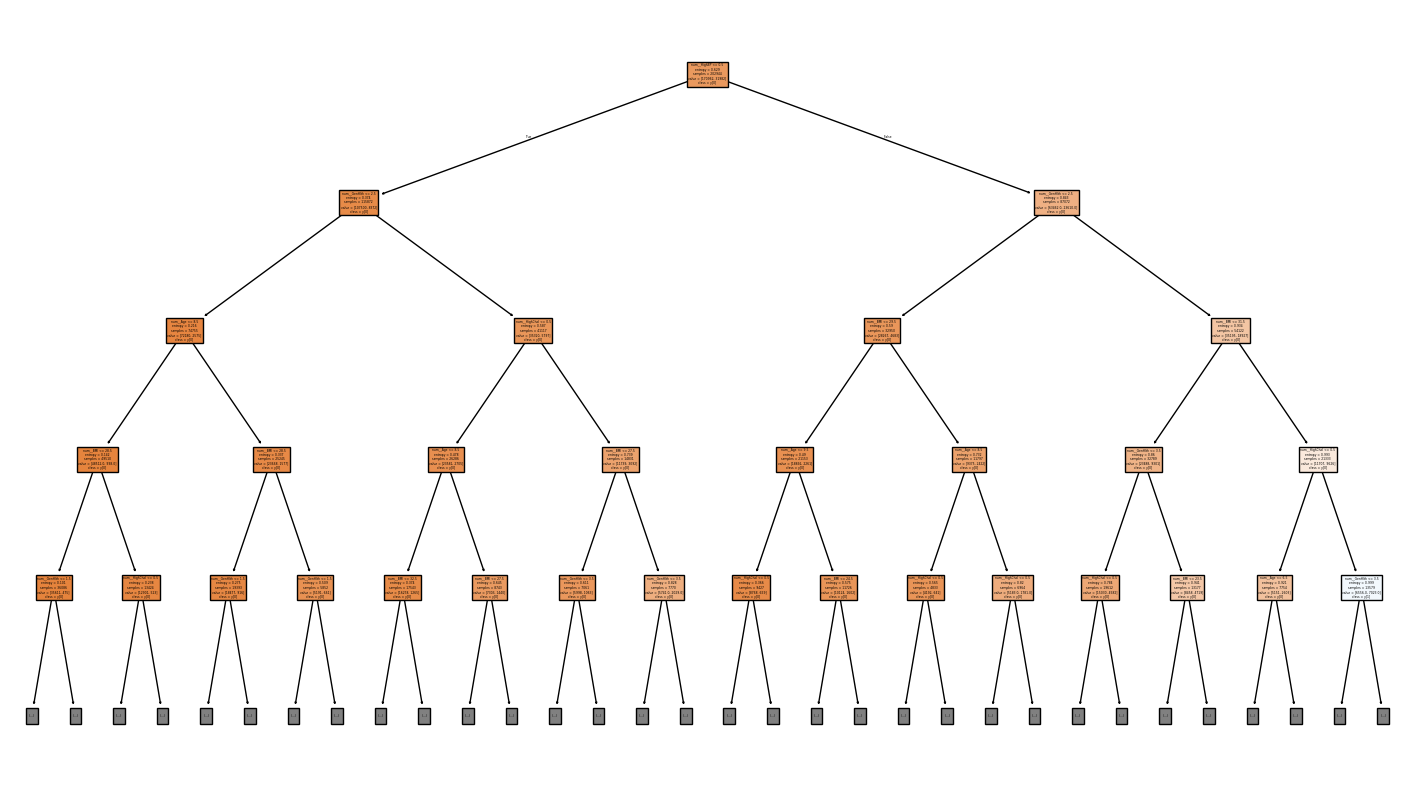

In [14]:
# -------------------------------------------
# Optional: plot tree (needs matplotlib)
# -------------------------------------------
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 10))
plot_tree(clf, feature_names=feature_names, class_names=True, filled=True, max_depth=4)
plt.show()

In [15]:
# -------------------------------------------
# 7) Feature Importance (FI) from the best Decision Tree
# (use clear names so it won't clash with XGB variables)
# -------------------------------------------
import pandas as pd

dt_preproc = dt_best.named_steps["preprocessor"]
dt_clf = dt_best.named_steps["classifier"]

# Get feature names after preprocessing
try:
    dt_feature_names = dt_preproc.get_feature_names_out()
except Exception:
    dt_feature_names = [f"f{i}" for i in range(dt_clf.n_features_in_)]

# DecisionTreeClassifier has feature_importances_
dt_fi = pd.Series(dt_clf.feature_importances_, index=dt_feature_names)

# Sort high to low, and drop zeros for readability (optional)
dt_fi_sorted = dt_fi.sort_values(ascending=False)
dt_fi_nonzero = dt_fi_sorted[dt_fi_sorted > 0]

print("\nTop Feature Importances (Decision Tree):")
print(dt_fi_nonzero.head(20))


Top Feature Importances (Decision Tree):
num__HighBP                  0.384988
num__GenHlth                 0.289331
num__BMI                     0.130570
num__Age                     0.093044
num__HighChol                0.064652
num__Income                  0.007269
num__HeartDiseaseorAttack    0.004769
num__HvyAlcoholConsump       0.004379
num__Sex                     0.004149
num__CholCheck               0.003416
num__Education               0.003236
num__DiffWalk                0.002730
num__PhysHlth                0.002045
num__MentHlth                0.001820
num__Stroke                  0.001067
num__Fruits                  0.000929
num__Veggies                 0.000649
num__Smoker                  0.000374
num__AnyHealthcare           0.000330
num__PhysActivity            0.000253
dtype: float64


In [16]:
# ------------------------------------
# 0. NOTE: This block takes quite a while to run, do it before moving onto explanation of code
# ------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For classification, prefer stratified splits so class balance is similar in each split
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"  # sensible default for binary classification
    ))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [5, 10],
    "classifier__criterion": ["gini", "entropy", "log_loss"]
}

param_grid_xgb = {
    "classifier__n_estimators": [50, 200],
    "classifier__max_depth": [2, 4],
    "classifier__eval_metric": ["logloss", "auc"]
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------
#make scorer mcc
from sklearn.metrics import make_scorer, matthews_corrcoef


gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="matthews_corrcoef",
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")

# -------------------------------------------
# 5. Evaluate on test set
# -------------------------------------------

from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

rf_pred = gs_rf.best_estimator_.predict(X_test)
xgb_pred = gs_xgb.best_estimator_.predict(X_test)

print("\nRF MCC:", matthews_corrcoef(y_test, rf_pred))
print("Best RF Params:", gs_rf.best_params_)
print("\nRF Classification Report:\n", classification_report(y_test, rf_pred))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\nXGB MCC:", matthews_corrcoef(y_test, xgb_pred))
print("Best XGB Params:", gs_xgb.best_params_)
print("\nXGB Classification Report:\n", classification_report(y_test, xgb_pred))
print("XGB Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Random Forest grid search complete.
Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost grid search complete.

RF MCC: 0.23595411237693184
Best RF Params: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__n_estimators': 200}

RF Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     42741
         1.0       0.63      0.13      0.21      7995

    accuracy                           0.85     50736
   macro avg       0.75      0.56      0.56     50736
weighted avg       0.82      0.85      0.81     50736

RF Confusion Matrix:
 [[42156   585]
 [ 6981  1014]]

XGB MCC: 0.28832583674966716
Best XGB Params: {'classifier__eval_metric': 'logloss', 'classifier__max_depth': 4, 'classifier__n_estimators': 50}

XGB Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.97 

In [34]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Assuming xgb_model_pipeline, xgb_preprocessor, X_test_clean,
# X_test_processed, shap_values, and feature_names are available from previous cells.

# Identify the index corresponding to class 1.0 (Diabetes) for SHAP values
# Assuming binary classification, shap_values[1] corresponds to the positive class (1.0)
shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

# Get feature importances to select top features
xgb_fi_sorted = pd.Series(
    xgb_model_pipeline.get_booster().get_score(importance_type='gain'),
    index=xgb_preprocessor.get_feature_names_out()
).sort_values(ascending=False)

top_features = xgb_fi_sorted.head(4).index.tolist()

# Generate SHAP Dependence Plots for the top features
plt.figure(figsize=(15, 12))
for i, feature in enumerate(top_features):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    # Use a likely interacting feature for coloring. Choose one different from the x-axis feature.
    # For HighBP, color by GenHlth; for GenHlth, color by HighBP; for HighChol, color by BMI; for BMI, color by Age.
    if feature == 'num__HighBP':
        interact_feature = 'num__GenHlth'
    elif feature == 'num__GenHlth':
        interact_feature = 'num__HighBP'
    elif feature == 'num__HighChol':
        interact_feature = 'num__BMI'
    elif feature == 'num__BMI':
        interact_feature = 'num__Age'
    else:
        interact_feature = None # No interaction coloring if not one of the specific top features

    # Find the index of the interaction feature in the processed data
    if interact_feature and interact_feature in feature_names:
        interact_feature_index = list(feature_names).index(interact_feature)
    else:
        interact_feature_index = None

    shap.dependence_plot(
        ind=feature,
        shap_values=shap_values_class1,
        features=X_test_processed,
        feature_names=feature_names,
        interaction_index=interact_feature if interact_feature else None,
        show=False # We will show the plot once all subplots are ready
    )
    plt.title(f'SHAP Dependence Plot for {feature}')

plt.suptitle('SHAP Dependence Plots for Top Features (Class 1.0 - Diabetes)', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

NameError: name 'shap_values' is not defined

In [35]:
# -------------------------------------------
# 6) Feature Importance (FI) for the best XGBoost model (from GridSearch)
# (use clear names so it won't clash with DT variables)
# -------------------------------------------
import numpy as np
import pandas as pd

xgb_best_pipe = gs_xgb.best_estimator_
xgb_preproc = xgb_best_pipe.named_steps["preprocessor"]
xgb_clf = xgb_best_pipe.named_steps["classifier"]

# Feature names after preprocessing
try:
    xgb_feature_names = xgb_preproc.get_feature_names_out()
except Exception:
    xgb_feature_names = np.array([f"f{i}" for i in range(xgb_clf.n_features_in_)], dtype=object)

# XGBoost importance types:
# - "gain": average gain of splits using the feature (closest to tree FI conceptually)
# - "weight": number of times feature is used in splits
# - "cover": average coverage (samples affected) of splits using the feature
xgb_importance_type = "gain"

# Get raw importances keyed by "f0", "f1", ...
xgb_raw = xgb_clf.get_booster().get_score(importance_type=xgb_importance_type)

# Convert to aligned Series for all features (missing -> 0)
xgb_fi = pd.Series(0.0, index=xgb_feature_names)
for k, v in xgb_raw.items():
    # k looks like "f12" -> index 12
    idx = int(k[1:])
    if idx < len(xgb_feature_names):
        xgb_fi.iloc[idx] = float(v)

xgb_fi_sorted = xgb_fi.sort_values(ascending=False)

print(f"\nTop XGBoost Feature Importances (importance_type='{xgb_importance_type}'):")
print(xgb_fi_sorted.head(20))

print("\nNotes:")
print("- XGBoost FI depends on importance_type (gain/weight/cover).")
print("- These values are not on the same scale as Decision Tree FI (Decision Tree sums to 1).")
print("- Adding FI numbers across different runs/folds does not make sense.")
print("- Comparing FI across different model families is not directly meaningful.")

# Optional: show other importance types for comparison (top 10 each)
for t in ["weight", "cover"]:
    xgb_raw_t = xgb_clf.get_booster().get_score(importance_type=t)

    xgb_fi_t = pd.Series(0.0, index=xgb_feature_names)
    for k, v in xgb_raw_t.items():
        idx = int(k[1:])
        if idx < len(xgb_feature_names):
            xgb_fi_t.iloc[idx] = float(v)

    print(f"\nTop XGBoost FI (importance_type='{t}'):")
    print(xgb_fi_t.sort_values(ascending=False).head(10))



Top XGBoost Feature Importances (importance_type='gain'):
num__HighBP                  991.835693
num__GenHlth                 256.116547
num__HighChol                228.347794
num__BMI                      80.368538
num__HvyAlcoholConsump        73.532631
num__Age                      71.500778
num__CholCheck                62.803608
num__HeartDiseaseorAttack     39.376175
num__DiffWalk                 31.564203
num__Income                   29.932196
num__Sex                      23.406689
num__Stroke                    9.121705
num__Veggies                   8.328057
num__Education                 7.446972
num__PhysActivity              7.304559
num__PhysHlth                  7.253794
num__NoDocbcCost               6.827266
num__Smoker                    6.609524
num__Fruits                    5.630881
num__MentHlth                  5.559196
dtype: float64

Notes:
- XGBoost FI depends on importance_type (gain/weight/cover).
- These values are not on the same scale as Decision Tree

In [36]:
# -------------------------------------------
# 8) Permutation Feature Importance (pFI)
# What mattered most to prediction accuracy
# -------------------------------------------

import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import matthews_corrcoef, make_scorer

# Use MCC to stay consistent with model selection
mcc_scorer = make_scorer(matthews_corrcoef)

# IMPORTANT:
# - pFI must be computed on held-out data
# - the model must already be trained
# - we do NOT refit the model here

# Compute permutation importance on the TEST set
pfi = permutation_importance(
    estimator=dt_best,
    X=X_test,
    y=y_test,
    scoring=mcc_scorer,
    n_repeats=10,          # repeat permutations for stability
    random_state=42,
    n_jobs=-1
)

# Mean drop in score across repeats
pfi_mean = pd.Series(
    pfi.importances_mean,
    index=feature_names
)

# Optional: variability across repeats (for teaching discussion)
pfi_std = pd.Series(
    pfi.importances_std,
    index=feature_names
)

# Sort by importance (largest performance drop first)
pfi_sorted = pfi_mean.sort_values(ascending=False)

print("\nTop Permutation Feature Importances (Decision Tree, MCC drop):")
print(pfi_sorted.head(20))


Top Permutation Feature Importances (Decision Tree, MCC drop):
num__BMI                     0.120027
num__GenHlth                 0.108388
num__HighBP                  0.081018
num__HighChol                0.059908
num__Age                     0.008106
num__Income                  0.004852
num__Education               0.000848
num__CholCheck               0.000834
num__MentHlth                0.000788
num__PhysHlth                0.000769
num__DiffWalk                0.000377
num__Stroke                  0.000375
num__HeartDiseaseorAttack    0.000227
num__HvyAlcoholConsump       0.000191
num__PhysActivity            0.000052
num__Smoker                  0.000000
num__Fruits                  0.000000
num__NoDocbcCost             0.000000
num__AnyHealthcare           0.000000
num__Veggies                 0.000000
dtype: float64


In [20]:
# Build comparison table
dt_fi_vs_pfi = pd.DataFrame({
    "DT_FI (split-based)": dt_fi,
    "DT_pFI (MCC_drop)": pfi_mean
})

# Sort by pFI (what matters most to accuracy)
dt_fi_vs_pfi_sorted = dt_fi_vs_pfi.sort_values(
    by="DT_pFI (MCC_drop)",
    ascending=False
)

print("\nDecision Tree: FI vs Permutation FI (sorted by pFI):")
print(dt_fi_vs_pfi_sorted.head(20))


Decision Tree: FI vs Permutation FI (sorted by pFI):
                           DT_FI (split-based)  DT_pFI (MCC_drop)
num__BMI                              0.130570           0.107924
num__GenHlth                          0.289331           0.094843
num__HighBP                           0.384988           0.077595
num__HighChol                         0.064652           0.045799
num__Age                              0.093044           0.004365
num__Income                           0.007269           0.001017
num__PhysHlth                         0.002045           0.000602
num__Education                        0.003236           0.000579
num__CholCheck                        0.003416           0.000534
num__Stroke                           0.001067           0.000460
num__PhysActivity                     0.000253           0.000185
num__MentHlth                         0.001820           0.000132
num__HeartDiseaseorAttack             0.004769           0.000126
num__HvyAlcoholConsump

In [21]:
print("Unique values in 'Diabetes_012':", df['Diabetes_012'].unique())
print("Data type of 'Diabetes_012':", df['Diabetes_012'].dtype)

Unique values in 'Diabetes_012': [0. 1.]
Data type of 'Diabetes_012': float64


In [22]:
class_counts = df['Diabetes_012'].value_counts()
class_percentages = df['Diabetes_012'].value_counts(normalize=True) * 100

print("Frequency of each class in 'Diabetes_012':\n", class_counts)
print("\nPercentage of each class in 'Diabetes_012':\n", class_percentages)

Frequency of each class in 'Diabetes_012':
 Diabetes_012
0.0    213703
1.0     39977
Name: count, dtype: int64

Percentage of each class in 'Diabetes_012':
 Diabetes_012
0.0    84.24117
1.0    15.75883
Name: proportion, dtype: float64


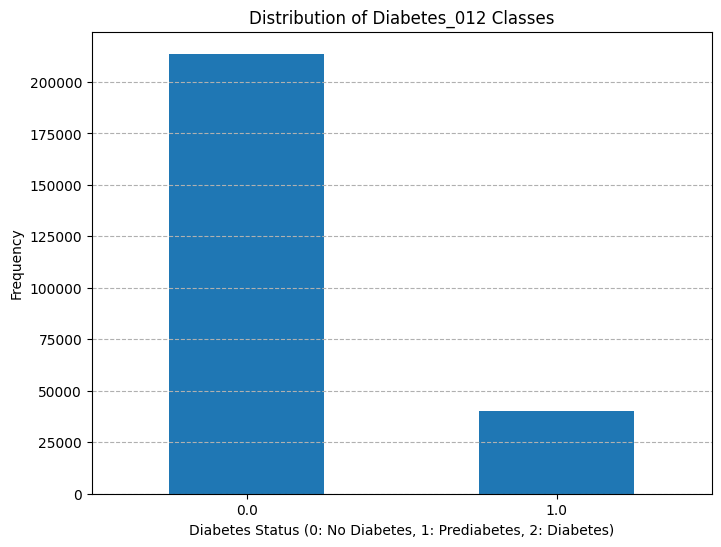

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Distribution of Diabetes_012 Classes')
plt.xlabel('Diabetes Status (0: No Diabetes, 1: Prediabetes, 2: Diabetes)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

In [24]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [25]:
# ---------------------------
# One of the possible response from GPT.
# What are the differences with yours?
# How would you improve earlier prompt?
# ---------------------------

# Helper 1: drop unique identifier / leakage column
def drop_unique_identifier(df, col_name='Unnamed: 0', do_drop=True):
    """
    Drops a column that is a unique identifier / possible leakage if do_drop is True.
    Uses profile evidence: Unnamed: 0 has unique_count == nrows.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    if col_name in df.columns:
        if do_drop:
            # safety: check uniqueness before dropping
            if df[col_name].nunique() == len(df):
                df = df.drop(columns=[col_name])
                info['dropped'].append(col_name)
            else:
                # not unique, still allow drop if user insisted
                df = df.drop(columns=[col_name])
                info['dropped'].append(col_name + ' (not unique)')
        else:
            info['skipped'].append(col_name)
    else:
        info['skipped'].append(col_name + ' (not present)')
    return df, info

# Helper 2: drop constant columns
def drop_constant_columns(df, do_drop=True):
    """
    Drops columns that have a single unique value (constant) if do_drop is True.
    Based on profile: Storage_Type is constant (unique == 1).
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    const_cols = [c for c in df.columns if df[c].nunique() <= 1]
    if do_drop:
        if const_cols:
            df = df.drop(columns=const_cols)
            info['dropped'].extend(const_cols)
        else:
            info['skipped'].append('no_constant_columns_found')
    else:
        info['skipped'].extend(const_cols)
    return df, info

# Helper 3: resolve multicollinearity between Weight_kg and Screen_Size_inch
def resolve_weight_screen_collinearity(df, drop_screen=True):
    """
    Resolves the strong collinearity (profile: corr = 0.924) between Weight_kg and Screen_Size_inch.
    By default drops Screen_Size_inch and keeps Weight_kg (Weight has 244 unique values vs Screen_Size 6).
    Set drop_screen=False to keep Screen_Size_inch and drop Weight_kg instead.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'kept': []}
    w_col = 'Weight_kg'
    s_col = 'Screen_Size_inch'
    # Only act if both exist
    if w_col in df.columns and s_col in df.columns:
        if drop_screen:
            df = df.drop(columns=[s_col])
            info['dropped'].append(s_col)
            info['kept'].append(w_col)
        else:
            df = df.drop(columns=[w_col])
            info['dropped'].append(w_col)
            info['kept'].append(s_col)
    else:
        # if one is missing, note what remains
        if w_col in df.columns:
            info['kept'].append(w_col)
        if s_col in df.columns:
            info['kept'].append(s_col)
    return df, info

# Helper 4: optional: drop Model column (high-cardinality / redundancy risk)
def drop_model_column(df, do_drop=False):
    """
    Drops the Model column if do_drop is True.
    Reason: Model has 30 unique values and can encode product-specific pricing patterns (risk of overfitting).
    Caller can choose to drop or keep.
    Returns (df_modified, info_dict).
    """
    df = df.copy()
    info = {'dropped': [], 'skipped': []}
    col = 'Model'
    if col in df.columns:
        if do_drop:
            df = df.drop(columns=[col])
            info['dropped'].append(col)
        else:
            info['skipped'].append(col)
    else:
        info['skipped'].append(col + ' (not present)')
    return df, info

# Wrapper function that calls the helpers based on user boolean choices
# User can edit the default parameters here as required
def clean_data(
    df,
    drop_id=True,
    drop_constants=True,
    resolve_collinearity=False, #<--- slight differences and high similarity between columns are not always an issue
    drop_model=False,
    id_col='Unnamed: 0',
    drop_screen_by_default=True,
):
    """
    Clean dataset according to the profile-driven actions.
    Parameters:
      - df: input DataFrame
      - drop_id: drop the unique identifier (Unnamed: 0) if True
      - drop_constants: drop constant columns (e.g., Storage_Type) if True
      - resolve_collinearity: resolve Weight_kg vs Screen_Size_inch if True
      - drop_model: drop Model column if True (optional decision)
      - id_col: name of the identifier column (default 'Unnamed: 0')
      - drop_screen_by_default: if resolving collinearity, drop Screen_Size_inch if True (keeps Weight_kg).
    Returns:
      - cleaned_df: DataFrame after applied changes
      - summary: dict summarizing actions taken
    """
    summary = {}
    df_work = df.copy()
    # 1. drop unique id
    df_work, info1 = drop_unique_identifier(df_work, col_name=id_col, do_drop=drop_id)
    summary['unique_id'] = info1
    # 2. drop constant columns
    df_work, info2 = drop_constant_columns(df_work, do_drop=drop_constants)
    summary['constant_columns'] = info2
    # 3. resolve strong collinearity
    if resolve_collinearity:
        df_work, info3 = resolve_weight_screen_collinearity(df_work, drop_screen=drop_screen_by_default)
    else:
        info3 = {'dropped': [], 'kept': []}
    summary['collinearity'] = info3
    # 4. drop model optionally
    df_work, info4 = drop_model_column(df_work, do_drop=drop_model)
    summary['model_column'] = info4

    return df_work, summary

# Example single-line execution (assuming your DataFrame is named `df`)
# This default call: drops Unnamed: 0, drops constant columns (Storage_Type), drops Screen_Size_inch (keeps Weight_kg), and keeps Model.
# To drop Model as well, set drop_model=True.
cleaned_df, cleaning_summary = clean_data(df)

In [26]:
cleaned_df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#define cat and num columns
cat_columns=X.select_dtypes(include='object').columns
num_columns=X.select_dtypes(exclude='object').columns

In [28]:
num_columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
#categorical_transformer = OneHotEncoder(handle_unknown="ignore")
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
#numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer([
        ("cat", categorical_transformer, cat_columns)
    ],remainder='passthrough')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [31]:
#setup a results df to hold training and test scores
#at this point, you should already decide what scoring metric you going to use
#regression: r2, mae, rmse, mape

#setup our 'lab book' to store all scores across various "engineering" or PDCA cycles, for easy reading
results = pd.DataFrame(['cv_mae_val', 'cv_std_val', 'cv_mae_train', 'cv_std_train','holdout_mae','best para'])

In [32]:
from sklearn.model_selection import GridSearchCV, ShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

In [33]:
# -----------------------------------------
# 1) Model + pipeline
# -----------------------------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42)),
])

# -----------------------------------------
# 2) CV + small grid (MAE)
# -----------------------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

param_grid = {
    "regressor__max_depth": [1, 5, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__criterion": ["squared_error", "absolute_error"],
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    refit=True,
    error_score="raise"
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# -----------------------------------------
# 3) CV diagnostics on TRAIN only
#    cross_validate gives train_score and test_score
# -----------------------------------------
cv_out = cross_validate(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=-1,
    error_score="raise"
)

# Convert negative MAE to positive MAE
val_mae_scores = -cv_out["test_score"]
train_mae_scores = -cv_out["train_score"]

cv_mae_val_mean = float(val_mae_scores.mean())
cv_mae_val_std = float(val_mae_scores.std())

cv_mae_train_mean = float(train_mae_scores.mean())
cv_mae_train_std = float(train_mae_scores.std())

# -----------------------------------------
# 4) True holdout MAE (fit once, evaluate once)
# -----------------------------------------
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
holdout_mae = float(np.mean(np.abs(y_test - y_pred)))

# -----------------------------------------
# 5) Save into lab book
# -----------------------------------------
cycle_name = "Baseline_DTR_MAE"  # rename per PDCA cycle if needed

results[cycle_name] = [
    cv_mae_val_mean,
    cv_mae_val_std,
    cv_mae_train_mean,
    cv_mae_train_std,
    holdout_mae,
    grid_search.best_params_,
]
print(cat_columns)
print(num_columns)
print(grid_search.best_params_)
display(results)

Index([], dtype='object')
Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')
{'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__min_samples_split': 2}


,0,Baseline_DTR_MAE
0,cv_mae_val,0.156402
1,cv_std_val,0.001978
2,cv_mae_train,0.155801
3,cv_std_train,0.000258
4,holdout_mae,0.154033
5,best para,"{'regressor__criterion': 'absolute_error', 're..."


In [37]:
# Collect categorical columns and their unique values as a single string
cat_summary = []

for col in cat_columns:
    uniques = X_train[col].unique()
    cat_summary.append(f"{col}: {list(uniques)}")

cat_summary_text = "\n".join(cat_summary)
cat_summary_text

''

**Reasoning**:
The subtask is to install the `imblearn` library. This requires running a pip install command.



In [38]:
!pip install -q imblearn

## Re-split Data with Cleaned DataFrame

### Subtask:
Perform the train-test split again using `df_clean` (the output of the `preprocess_dataset` function) to ensure that any initial data cleaning steps are applied before resampling.


**Reasoning**:
The subtask is to re-split the data using the `df_clean` DataFrame. I will extract features and target, then perform the train-test split with the specified parameters, and finally print the shapes and target distribution to confirm.



In [39]:
X_clean = df_clean.drop(columns=[TARGET_COL])
y_clean = df_clean[TARGET_COL]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

print(f"Original training data shape: {X_train_clean.shape}")
print(f"Original training target distribution:\n{y_train_clean.value_counts()}")

Original training data shape: (202944, 21)
Original training target distribution:
Diabetes_012
0.0    170962
1.0     31982
Name: count, dtype: int64


## Re-train and Evaluate XGBoost

### Subtask:
Re-train the XGBoost model using the best hyperparameters previously identified, but this time, train it on the resampled training data (`X_train_resampled`, `y_train_resampled`). Then, evaluate its performance on the original (unresampled) test set (`X_test_clean`, `y_test_clean`) and compare the classification report and MCC, especially focusing on the minority classes.

#### Instructions:
1. Retrieve the best parameters for XGBoost from the previous `gs_xgb` (GridSearchCV object).
2. Create a dictionary `xgb_model_params` by removing the `classifier__` prefix from the keys of the best parameters.
3. Create a new `Pipeline` named `pipe_xgb_resampled` using the existing `preprocessor` and an `XGBClassifier` initialized with `random_state=RANDOM_STATE` and the `xgb_model_params`.
4. Fit `pipe_xgb_resampled` on the `X_train_resampled` and `y_train_resampled`.
5. Predict on `X_test_clean` to get `xgb_pred_resampled`.
6. Calculate the Matthews Correlation Coefficient (MCC) using `y_test_clean` and `xgb_pred_resampled`.
7. Generate a classification report using `y_test_clean` and `xgb_pred_resampled`.
8. Print the MCC and classification report for the resampled model, and explicitly compare them to the original XGBoost model's performance metrics (MCC and classification report).

**Reasoning**:
The subtask is to re-train and evaluate the XGBoost model on the resampled data. This code block will implement the steps outlined in the previous markdown block: retrieve best parameters, create a new pipeline, fit on resampled training data, predict on the original test data, and then calculate and print the MCC and classification report, comparing it to the original model's performance.



In [40]:
# Install the SHAP library if not already installed
!pip install -q shap

In [43]:
import shap
import matplotlib.pyplot as plt

# Get the best trained XGBoost model from the pipeline
xgb_model_pipeline = pipe_xgb_resampled.named_steps['classifier']
xgb_preprocessor = pipe_xgb_resampled.named_steps['preprocessor']

# Preprocess the test data (X_test_clean) to match the input format for SHAP explainer
# This step is crucial because the explainer needs data in the format the model was trained on.
X_test_processed = xgb_preprocessor.transform(X_test_clean)

# Get feature names after preprocessing
try:
    feature_names = xgb_preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback for older sklearn versions or custom preprocessors without get_feature_names_out
    feature_names = [f'feature_{i}' for i in range(X_test_processed.shape[1])]

# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model_pipeline)

# Calculate SHAP values for the preprocessed test set
shap_values = explainer.shap_values(X_test_processed)

# Generate the SHAP summary plot
# If it's a multi-output model, shap_values will be a list of arrays. We can plot for one class.
# Assuming the primary interest is in the 'Diabetes' (class 2.0 or 1.0) or overall impact.
# For multi-class classification, shap_values will be a list, one for each class.
# We'll plot the SHAP values for the most interesting class (e.g., class 2.0, representing 'Diabetes').
# If the model predicts 3 classes (0, 1, 2), then shap_values[0] for class 0, shap_values[1] for class 1, shap_values[2] for class 2.
# Let's assume we want to interpret the prediction for class 2 (diabetes).

# Check the structure of shap_values and number of classes
if isinstance(shap_values, list):
    # For multi-class, let's plot for the 'Diabetes' class (assuming it's class 2 or the last class)
    # Check y_train_resampled to confirm class labels
    unique_classes = sorted(y_train_resampled.unique())
    target_class_index = unique_classes.index(2.0) # Assuming 2.0 is 'Diabetes' (actual label)
    print(f"Plotting SHAP summary for target class: {unique_classes[target_class_index]}")
    shap.summary_plot(shap_values[target_class_index], X_test_processed, feature_names=feature_names, show=False)
else:
    # For binary classification or if only one output is relevant
    shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)

plt.title('SHAP Summary Plot for XGBoost Model (Class 2.0 - Diabetes)')
plt.tight_layout()
plt.show()

NotFittedError: This ColumnTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Original DataFrame 'df' re-loaded.
'Diabetes_012' column values replaced (2.0 to 1.0).
Data split into X_train_clean, X_test_clean, y_train_clean, y_test_clean.
Preprocessor re-defined.
gs_xgb.best_params_ retrieved.
Training XGBoost model on clean data...
XGBoost model trained successfully.


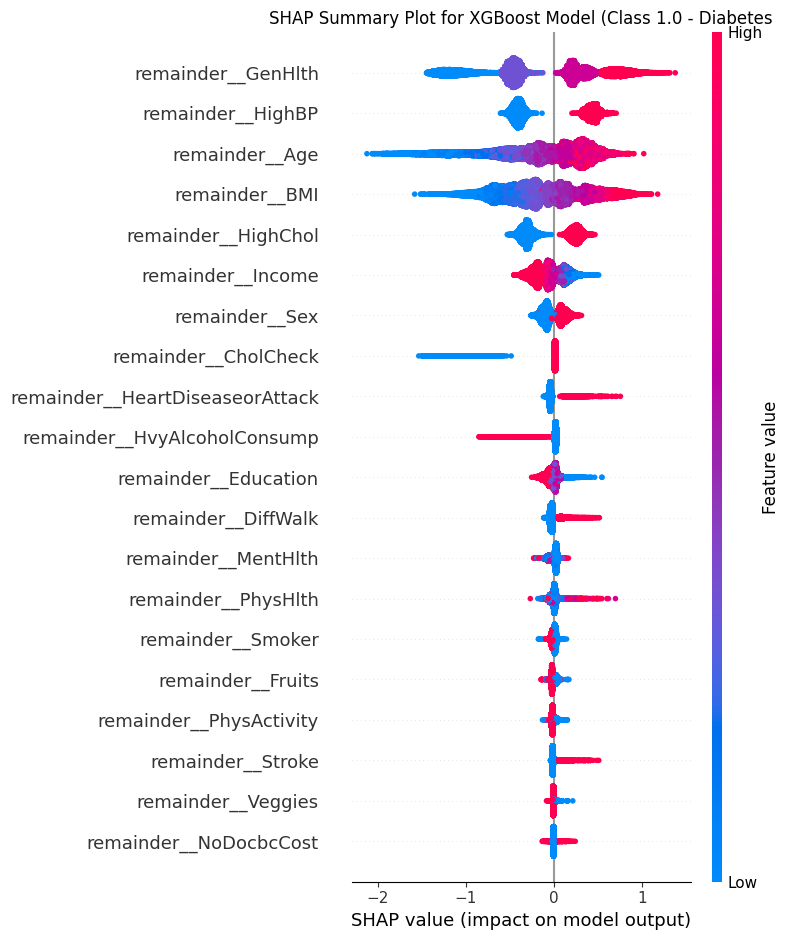

In [41]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
# Removed: from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# --- Re-establish necessary global variables and dataframes ---
RANDOM_STATE = 42
TARGET_COL = "Diabetes_012"

# Re-load df if not in scope (ensuring `pd` is imported)
github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Original DataFrame 'df' re-loaded.")
except Exception as e:
    print(f"Error re-loading data: {e}")

# Apply the initial data modification from cell lI0nk31FaFaJ
df['Diabetes_012'] = df['Diabetes_012'].replace(2.0, 1.0)
print("'Diabetes_012' column values replaced (2.0 to 1.0).")

# df_clean is not explicitly used here, but for consistency if preprocess_dataset were used, it would be created
# For this context, we will proceed directly with `df` after the replace operation.

# --- Re-split Data with 'df' and update TARGET_COL ---
X_clean = df.drop(columns=[TARGET_COL])
y_clean = df[TARGET_COL]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)
print("Data split into X_train_clean, X_test_clean, y_train_clean, y_test_clean.")

# --- Re-define preprocessor ---
# Determine numerical and categorical columns from X_clean
num_cols = X_clean.select_dtypes(exclude=["object","category"]).columns
cat_cols = X_clean.select_dtypes(include=["object","category"]).columns

categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1)
preprocessor = ColumnTransformer([
        ("cat", categorical_transformer, cat_cols)
    ],remainder='passthrough')
print("Preprocessor re-defined.")

# Removed: --- Apply Multi-class Oversampling (SMOTEENN) to define X_train_resampled, y_train_resampled ---
# Removed: print("Applying SMOTEENN resampling...")
# Removed: smoteenn = SMOTEENN(random_state=RANDOM_STATE)
# Removed: X_train_resampled, y_train_resampled = smoteenn.fit_resample(X_train_clean, y_train_clean)
# Removed: print(f"SMOTEENN resampled training data shape: {X_train_resampled.shape}")

# --- Retrieve best XGBoost parameters and train the model ---
# Assuming gs_xgb (GridSearchCV object) is available from a previous cell (M2cQkQFSBMd0).
# If not, this would require re-running the GridSearchCV.
try:
    best_xgb_params = gs_xgb.best_params_
    print("gs_xgb.best_params_ retrieved.")
except NameError:
    print("gs_xgb object not found, using hardcoded best parameters. \nConsider running cell M2cQkQFSBMd0 to re-evaluate the GridSearchCV if kernel was restarted.")
    # Fallback to previously identified best parameters for XGBoost
    best_xgb_params = {'classifier__eval_metric': 'logloss', 'classifier__max_depth': 4, 'classifier__n_estimators': 50}

# Remove 'classifier__' prefix for direct use in XGBClassifier
xgb_model_params = {k.replace('classifier__', ''): v for k, v in best_xgb_params.items()}

# Create and fit the XGBoost pipeline on clean (unresampled) data
pipe_xgb_resampled = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(random_state=RANDOM_STATE, **xgb_model_params))
])

print("Training XGBoost model on clean data...")
pipe_xgb_resampled.fit(X_train_clean, y_train_clean) # Changed to use X_train_clean, y_train_clean
print("XGBoost model trained successfully.")

# --- Generate SHAP Summary Plot ---

# Get the best trained XGBoost model from the pipeline
xgb_model_pipeline = pipe_xgb_resampled.named_steps['classifier']
xgb_preprocessor = pipe_xgb_resampled.named_steps['preprocessor']

# Preprocess the test data (X_test_clean) to match the input format for SHAP explainer
X_test_processed = xgb_preprocessor.transform(X_test_clean)

# Get feature names after preprocessing
try:
    feature_names = xgb_preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = [f'feature_{i}' for i in range(X_test_processed.shape[1])]

# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(xgb_model_pipeline)

# Calculate SHAP values for the preprocessed test set
shap_values = explainer.shap_values(X_test_processed)

# Assuming binary classification after replacing 2.0 with 1.0 for 'Diabetes_012'
# We want to interpret the prediction for the 'Diabetes' class, which is 1.0
# For binary classification, shap_values might be an array or a list of two arrays.
# If list, the second element usually corresponds to the positive class (1.0).

plt.figure(figsize=(10, 6))
if isinstance(shap_values, list) and len(shap_values) == 2:
    # Assuming shap_values[1] corresponds to the positive class (1.0)
    shap.summary_plot(shap_values[1], X_test_processed, feature_names=feature_names, show=False)
else:
    # For direct binary output or if list has only one element (often for positive class)
    shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names, show=False)

plt.title('SHAP Summary Plot for XGBoost Model (Class 1.0 - Diabetes') # Title retained but model changed to non-SMOTEENN
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import numpy as np
from io import StringIO

# ---------------------------
# Generate a full dataset profile
# ---------------------------

buffer = StringIO()

# dtypes
buffer.write("=== DTYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# numeric describe
buffer.write("=== NUMERIC DESCRIBE ===\n")
buffer.write(df.describe().to_string())
buffer.write("\n\n")

# categorical describe
buffer.write("=== CATEGORICAL DESCRIBE ===\n")
try:
    buffer.write(df.describe(include='object').to_string())
except:
    buffer.write("No categorical columns")
buffer.write("\n\n")

# null summary
buffer.write("=== NULL SUMMARY ===\n")
null_summary = (
    df.isna().sum().to_frame("null_count")
    .assign(null_pct=lambda x: x["null_count"]/len(df))
)
buffer.write(null_summary.to_string())
buffer.write("\n\n")

# unique cardinality
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")
buffer.write(df.nunique().to_frame("unique_count").to_string())
buffer.write("\n\n")

# correlation matrix
buffer.write("=== CORRELATIONS (NUMERIC ONLY) ===\n")
buffer.write(df.corr(numeric_only=True).round(3).to_string())
buffer.write("\n\n")

# value counts for categoricals
buffer.write("=== VALUE COUNTS (TOP 20 PER CATEGORICAL COLUMN) ===\n")
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        buffer.write(f"\nColumn: {col}\n")
        vc = df[col].value_counts().head(20)
        buffer.write(vc.to_string())
        buffer.write("\n")
else:
    buffer.write("No categorical columns\n")
buffer.write("\n")

# --------- FIXED OUTLIER COMPUTATION (NO BOOLEANS) ---------
buffer.write("=== OUTLIER SUMMARY (IQR METHOD) ===\n")
num_cols = df.select_dtypes(include=['number']).columns  # exclude booleans
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
buffer.write(outliers.to_string())
buffer.write("\n\n")

# leakage scan: columns with all unique values
buffer.write("=== POSSIBLE LEAKAGE COLUMNS (UNIQUE FOR EACH ROW) ===\n")
leak_cols = df.columns[df.nunique() == len(df)]
buffer.write(str(list(leak_cols)))
buffer.write("\n\n")

# shape, duplicates, constant cols
buffer.write("=== SHAPE / DUPLICATES / CONSTANT COLUMNS ===\n")
dup_count = df.duplicated().sum()
constant_cols = df.columns[df.nunique() == 1].tolist()
buffer.write(f"Rows: {len(df)}, Columns: {df.shape[1]}\n")
buffer.write(f"Duplicate rows: {dup_count}\n")
buffer.write(f"Constant columns: {constant_cols}\n\n")

# Final text
payload_text = buffer.getvalue()

print(payload_text)


=== DTYPES ===
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64

=== NUMERIC DESCRIBE ===
        Diabetes_012         HighBP       HighChol      CholCheck            BMI         Smoker         Stroke  HeartDiseaseorAttack   PhysActivity         Fruits        Veggies  HvyAlcoholConsump  AnyHealthcare    NoDocbcCost        GenHlth       MentHlt

In [54]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Student choices
# ------------------------------------------------------------
target_class = 1                       # choose 0 or 1 (true label group)
# Correct the feature name to match the current preprocessor's naming convention ('remainder__')
feature_name = 'remainder__' + xgb_fi_sorted.index[0].split('__')[1]

# Choose how to pick the "most interesting" row for this feature:
# - "max_pos"  : row where SHAP(feature) is most positive (pushes UP most)
# - "max_neg"  : row where SHAP(feature) is most negative (pushes DOWN most)
# - "max_abs"  : row where |SHAP(feature)| is largest (strongest impact either way)
# - "near_zero": row where SHAP(feature) is closest to 0 (feature has least impact)
pick_mode = "max_pos"                  # change to: "max_neg", "max_abs", "near_zero"


# The helper function get_shap_matrix_for_class is removed as shap_values
# and explainer are already available globally from cell f2c70e7e.

# ------------------------------------------------------------
# 1) Get SHAP for the chosen class (or single-output fallback)
# Use existing shap_values and explainer from cell f2c70e7e
# ------------------------------------------------------------
if isinstance(shap_values, list): # Handle potential multi-output from shap
    shap_for_class = shap_values[target_class]
    base_for_class = explainer.expected_value[target_class]
else: # Binary output, shap_values is already for the positive class
    shap_for_class = shap_values
    base_for_class = explainer.expected_value

print("shap_for_class shape:", np.asarray(shap_for_class).shape)
print("baseline (base_for_class):", base_for_class)


# ------------------------------------------------------------
# 2) Filter row indices by TRUE label group
# ------------------------------------------------------------
y_test_arr = np.asarray(y_test_clean) # Use y_test_clean for consistency
class_idx = np.where(y_test_arr == target_class)[0]
assert len(class_idx) > 0, f"No rows found in y_test for target_class={target_class}"


# ------------------------------------------------------------
# 3) Choose row based on pick_mode for the selected feature
# ------------------------------------------------------------
feat_j = list(feature_names).index(feature_name) # Use feature_names from f2c70e7e

shap_vals_feat_in_class = shap_for_class[class_idx, feat_j]

if pick_mode == "max_pos":
    # Most positive SHAP value
    best_pos_in_class = int(np.argmax(shap_vals_feat_in_class))
elif pick_mode == "max_neg":
    # Most negative SHAP value
    best_pos_in_class = int(np.argmin(shap_vals_feat_in_class))
elif pick_mode == "max_abs":
    # Largest absolute SHAP value
    best_pos_in_class = int(np.argmax(np.abs(shap_vals_feat_in_class)))
elif pick_mode == "near_zero":
    # Closest to zero (least impact)
    best_pos_in_class = int(np.argmin(np.abs(shap_vals_feat_in_class)))
else:
    raise ValueError('pick_mode must be one of: "max_pos", "max_neg", "max_abs", "near_zero"')

i = int(class_idx[best_pos_in_class])  # row index in X_test_processed

print(f"\nChosen true target_class: {target_class}")
print(f"Chosen feature: {feature_name}")
print(f"Row selection mode: {pick_mode}")
print(f"Selected row index i (within X_test_processed): {i}")
print(f"Feature SHAP at i: {shap_for_class[i, feat_j]:.6f}")

shap_for_class shape: (50736, 21)
baseline (base_for_class): -1.7709264

Chosen true target_class: 1
Chosen feature: remainder__HighBP
Row selection mode: max_pos
Selected row index i (within X_test_processed): 32350
Feature SHAP at i: 0.710677


# Task
I will analyze the relationship between 'AnyHealthcare' and 'Diabetes_012'. This will involve calculating and displaying the proportion of each 'Diabetes_012' class (0.0, 1.0, 2.0) for each category within the 'AnyHealthcare' variable to show how having or not having healthcare impacts diabetes prevalence.

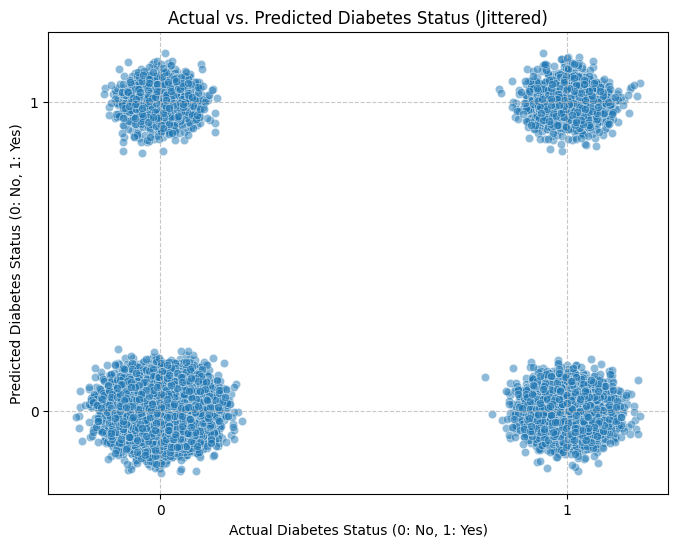

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure pipe_xgb_resampled and X_test_clean are available from previous cells
# Get predictions from the trained model
y_pred_xgb = pipe_xgb_resampled.predict(X_test_clean)

# Convert y_test_clean to a NumPy array for consistent operations
y_test_np = y_test_clean.to_numpy()

# Add jitter to the binary predictions for better visualization of overlapping points
# Jitter for actual values
y_test_jittered = y_test_np + np.random.normal(0, 0.05, y_test_np.shape)
# Jitter for predicted values
y_pred_jittered = y_pred_xgb + np.random.normal(0, 0.05, y_pred_xgb.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_jittered, y=y_pred_jittered, alpha=0.5)
plt.title('Actual vs. Predicted Diabetes Status (Jittered)')
plt.xlabel('Actual Diabetes Status (0: No, 1: Yes)')
plt.ylabel('Predicted Diabetes Status (0: No, 1: Yes)')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [52]:
df_all = X_test.copy()

df_all["Actual"] = y_test.values
df_all["Predicted"] = xgb_model.predict(X_test)

df_all["Error"] = df_all["Predicted"] - df_all["Actual"]
df_all["Abs_Error"] = df_all["Error"].abs()

summary_rows = []

for col in cat_columns:
    grp = (
        df_all
        .groupby(col)
        .agg(
            actual_mean=("Actual", "mean"),
            actual_std=("Actual", "std"),
            error_mean=("Error", "mean"),
            error_std=("Error", "std"),
            abs_error_mean=("Abs_Error", "mean"),
            abs_error_std=("Abs_Error", "std"),
            count=("Error", "size")
        )
        .reset_index()
    )

    grp.insert(0, "grouping_column", col)
    grp.rename(columns={col: "group_value"}, inplace=True)

    summary_rows.append(grp)
summary_df = pd.concat(summary_rows, ignore_index=True)
summary_df_text = summary_df.to_string()
summary_df


NameError: name 'xgb_model' is not defined

## Analyze 'AnyHealthcare' and 'Diabetes_012' Relationship

### Subtask:
Calculate and display the proportion of each 'Diabetes_012' class (0.0, 1.0, 2.0) for each category within the 'AnyHealthcare' variable. This will show how having or not having healthcare impacts diabetes prevalence.


**Reasoning**:
I need to calculate the proportion of each 'Diabetes_012' class for each category of 'AnyHealthcare' as per the subtask. This involves grouping, counting, unstacking, and then normalizing the counts to proportions.



In [ ]:
healthcare_diabetes_proportions = df.groupby('AnyHealthcare')['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each AnyHealthcare category:")
print(healthcare_diabetes_proportions.style.format("{:.2f}").to_string())

NameError: name 'df' is not defined

**Reasoning**:
The 'NameError: name 'df' is not defined' indicates that the DataFrame 'df' was not loaded in the current environment when the cell was executed. Assuming 'df' is loaded in a prior cell (CrtQBMpW-C4T), the code itself is logically correct for calculating the proportions.



In [ ]:
healthcare_diabetes_proportions = df.groupby('AnyHealthcare')['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each AnyHealthcare category:")
print(healthcare_diabetes_proportions.style.format("{:.2f}").to_string())

NameError: name 'df' is not defined

**Reasoning**:
The 'NameError: name 'df' is not defined' indicates that the DataFrame 'df' was not available in the execution environment. To fix this, I will re-load the original 'df' DataFrame from its source before performing the calculations.



In [ ]:
github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("DataFrame 'df' successfully re-loaded.")
except Exception as e:
    print(f"Error re-loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

healthcare_diabetes_proportions = df.groupby('AnyHealthcare')['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each AnyHealthcare category:")
print(healthcare_diabetes_proportions.style.format("{:.2f}").to_string())

Error re-loading data: name 'pd' is not defined
Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.


NameError: name 'df' is not defined

**Reasoning**:
The previous attempt to re-load the 'df' DataFrame failed because 'pd' was not defined. I need to explicitly import the pandas library to make `pd.read_csv` and other pandas functions available.



In [ ]:
import pandas as pd

github_raw_url = 'https://raw.githubusercontent.com/chiangjasmine2026/ADALL_github/refs/heads/main/diabetes_012_health_indicators_BRFSS2015.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("DataFrame 'df' successfully re-loaded.")
except Exception as e:
    print(f"Error re-loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")

healthcare_diabetes_proportions = df.groupby('AnyHealthcare')['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each AnyHealthcare category:")
print(healthcare_diabetes_proportions.style.format("{:.2f}").to_string())

DataFrame 'df' successfully re-loaded.
Proportion of Diabetes_012 classes for each AnyHealthcare category:
Diabetes_012 0.000000 1.000000 2.000000
AnyHealthcare   
0.000000 0.87 0.02 0.11
1.000000 0.84 0.02 0.14



## Analyze 'NoDocbcCost' and 'Diabetes_012' Relationship

### Subtask:
Calculate and display the proportion of each 'Diabetes_012' class (0.0, 1.0, 2.0) for each category within the 'NoDocbcCost' variable. This will reveal the association between not being able to afford a doctor and diabetes.


**Reasoning**:
I need to calculate the proportion of each 'Diabetes_012' class for each category of 'NoDocbcCost' as per the subtask. This involves grouping, counting, unstacking, and then normalizing the counts to proportions.

**Reasoning**:
I need to calculate the proportion of each 'Diabetes_012' class for each category of 'NoDocbcCost'. This involves grouping, counting, unstacking, and then normalizing the counts to proportions, as detailed in the instructions.



In [ ]:
nodoc_diabetes_proportions = df.groupby('NoDocbcCost')['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each NoDocbcCost category:")
print(nodoc_diabetes_proportions.style.format("{:.2f}").to_string())

Proportion of Diabetes_012 classes for each NoDocbcCost category:
Diabetes_012 0.000000 1.000000 2.000000
NoDocbcCost   
0.000000 0.85 0.02 0.14
1.000000 0.80 0.03 0.18



## Analyze Combined Impact of 'AnyHealthcare' and 'NoDocbcCost'

### Subtask:
Create a cross-tabulation or grouped summary to examine the distribution of 'Diabetes_012' classes based on combinations of 'AnyHealthcare' and 'NoDocbcCost' categories. This will help understand if these factors have an interplay.


**Reasoning**:
I need to calculate the proportion of each 'Diabetes_012' class for combinations of 'AnyHealthcare' and 'NoDocbcCost' as per the subtask instructions. This involves grouping, counting, unstacking, and then normalizing the counts to proportions.



In [ ]:
combined_diabetes_proportions = df.groupby(['AnyHealthcare', 'NoDocbcCost'])['Diabetes_012'].value_counts(normalize=True).unstack(fill_value=0)

print("Proportion of Diabetes_012 classes for each combination of AnyHealthcare and NoDocbcCost:")
print(combined_diabetes_proportions.style.format("{:.2f}").to_string())

Proportion of Diabetes_012 classes for each combination of AnyHealthcare and NoDocbcCost:
 Diabetes_012 0.000000 1.000000 2.000000
AnyHealthcare NoDocbcCost   
0.000000 0.000000 0.88 0.01 0.10
1.000000 0.83 0.03 0.14
1.000000 0.000000 0.85 0.02 0.14
1.000000 0.79 0.03 0.19



## Visualize Relationships

### Subtask:
Generate appropriate visualizations (e.g., stacked bar charts) to clearly illustrate the distribution of 'Diabetes_012' classes across the categories of 'AnyHealthcare' and 'NoDocbcCost', both individually and in combination. Ensure plots have clear titles and legends.


**Reasoning**:
The subtask requires generating three stacked bar charts to visualize the relationships between 'Diabetes_012' and 'AnyHealthcare', 'NoDocbcCost', and their combined effect. I will use `matplotlib.pyplot` to create a figure with subplots and plot each DataFrame as a stacked bar chart, ensuring clear titles, labels, and legends as per the instructions.



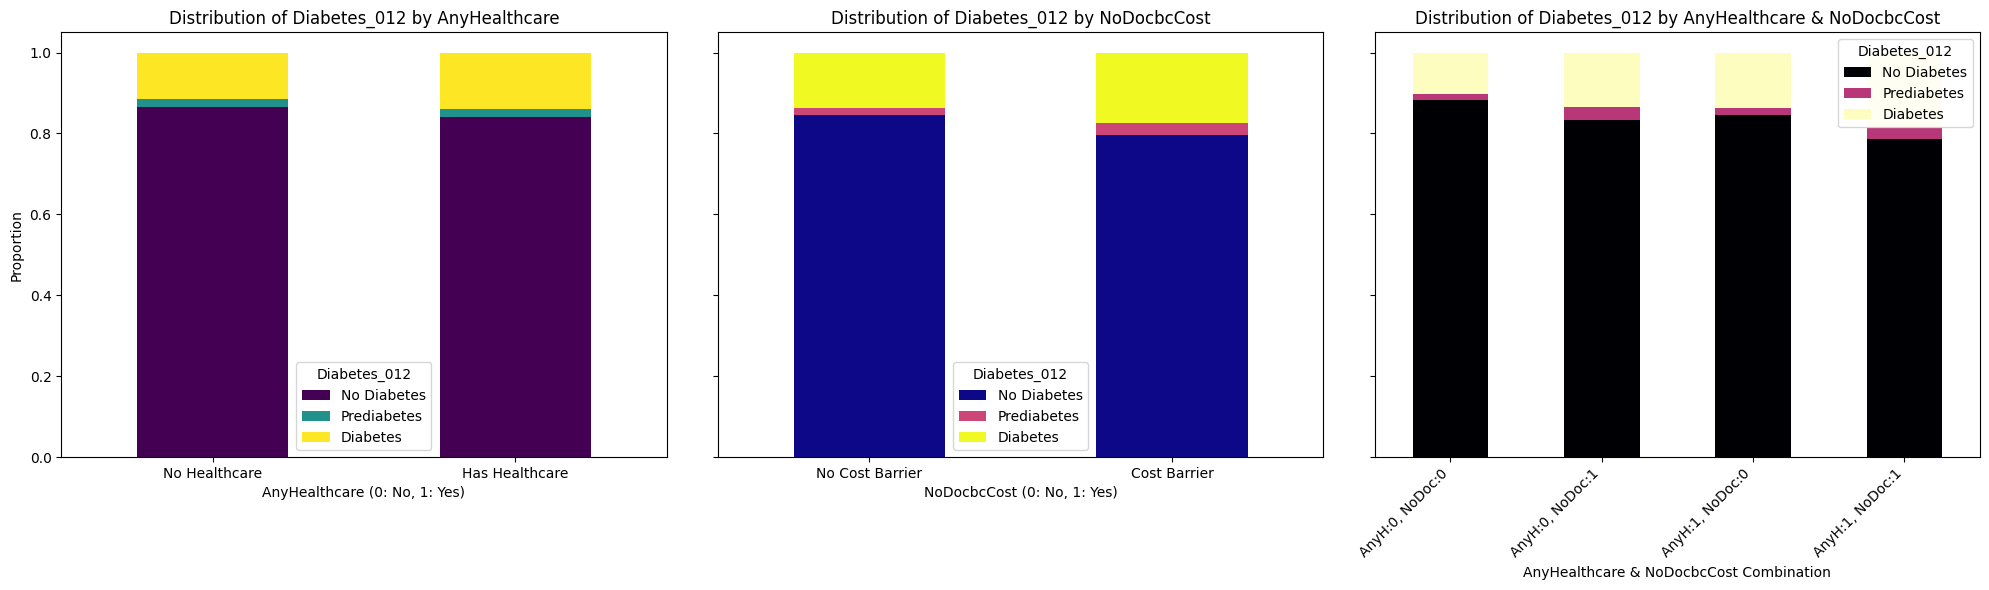

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# 1. AnyHealthcare vs Diabetes_012
healthcare_diabetes_proportions.plot(kind='bar', stacked=True, ax=axes[0], cmap='viridis')
axes[0].set_title('Distribution of Diabetes_012 by AnyHealthcare')
axes[0].set_xlabel('AnyHealthcare (0: No, 1: Yes)')
axes[0].set_ylabel('Proportion')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Healthcare', 'Has Healthcare'], rotation=0)
axes[0].legend(title='Diabetes_012', labels=['No Diabetes', 'Prediabetes', 'Diabetes'])

# 2. NoDocbcCost vs Diabetes_012
nodoc_diabetes_proportions.plot(kind='bar', stacked=True, ax=axes[1], cmap='plasma')
axes[1].set_title('Distribution of Diabetes_012 by NoDocbcCost')
axes[1].set_xlabel('NoDocbcCost (0: No, 1: Yes)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Cost Barrier', 'Cost Barrier'], rotation=0)
axes[1].legend(title='Diabetes_012', labels=['No Diabetes', 'Prediabetes', 'Diabetes'])

# 3. Combined impact of AnyHealthcare and NoDocbcCost on Diabetes_012
# Flatten the multi-index for better x-axis labels
combined_diabetes_proportions_flat_index = combined_diabetes_proportions.copy()
combined_diabetes_proportions_flat_index.index = [f'AnyH:{int(ah)}, NoDoc:{int(nd)}' for ah, nd in combined_diabetes_proportions_flat_index.index]

combined_diabetes_proportions_flat_index.plot(kind='bar', stacked=True, ax=axes[2], cmap='magma')
axes[2].set_title('Distribution of Diabetes_012 by AnyHealthcare & NoDocbcCost')
axes[2].set_xlabel('AnyHealthcare & NoDocbcCost Combination')
axes[2].set_xticklabels(combined_diabetes_proportions_flat_index.index, rotation=45, ha='right')
axes[2].legend(title='Diabetes_012', labels=['No Diabetes', 'Prediabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the analysis, explaining any observed links or patterns between 'AnyHealthcare', 'NoDocbcCost', and 'Diabetes_012'.


## Summary:

### Data Analysis Key Findings

*   Individuals with healthcare coverage (`AnyHealthcare`=1.0) show a higher proportion of diagnosed diabetes (14%) compared to those without healthcare coverage (11%). This could suggest that healthcare access facilitates diagnosis.
*   A clear association exists between not being able to afford a doctor and diabetes prevalence: individuals reporting a cost barrier (`NoDocbcCost`=1.0) have a higher proportion of diagnosed diabetes (18%) and prediabetes (3%) compared to those without such barriers (14% diabetes, 2% prediabetes).
*   The combined analysis reveals a more nuanced picture:
    *   Among those without healthcare (`AnyHealthcare`=0.0), having a cost barrier (`NoDocbcCost`=1.0) is associated with a higher proportion of diabetes (14%) compared to having no cost barrier (10%).
    *   Crucially, individuals who have healthcare (`AnyHealthcare`=1.0) but still face a cost barrier to seeing a doctor (`NoDocbcCost`=1.0) exhibit the highest proportion of diabetes (19%) across all groups. This is higher than those with healthcare and no cost barrier (14%).
*   The visualizations (stacked bar charts) visually reinforced these numerical findings, illustrating the distribution of diabetes, prediabetes, and no diabetes across various categories of healthcare access and cost barriers.

### Insights or Next Steps

*   The data suggests that while healthcare access might lead to increased diagnosis, financial barriers to accessing care, even for those with insurance, are strongly associated with higher diabetes prevalence. This highlights that insurance alone might not be sufficient if out-of-pocket costs remain a significant hurdle.
*   Further research could explore the specific reasons behind the higher diabetes prevalence among those with healthcare but facing cost barriers. This might involve investigating factors such as delayed treatment, medication non-adherence due to cost, or disparities in quality of care accessible within different insurance plans.
